# TP7 : Régression linéaire

Importez les bibliothèques suivantes.

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering, la PCA, la NMF, le MDS, l'Isomap et le KNN. Le présent TP utilisant la PCA, voici une cellule important la classe `PCA` ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)) de la bibliothèque `sklearn`. Regardez bien la documentation. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies.

In [2]:
from sklearn.decomposition import PCA

Importez les jeux de données.

In [3]:
## from google.colab import files
## data_to_load = files.upload()
## import io
## df_prices = pd.read_csv(io.BytesIO(data_to_load['prices.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_prices = pd.read_csv("prix.csv")
y = df_prices.values

print(X.shape)
print(f"Nombre de prix : {len(y)}")
print(f"Prix min : {y.min():.2f}, Prix max : {y.max():.2f}")

(2535, 784)
Nombre de prix : 2535
Prix min : 25.94, Prix max : 194.54


---

## Introduction : de la classification à la régression

Dans le TP précédent, nous avons travaillé sur un problème de classification : prédire à quelle classe appartient une image (T-shirt, pantalon, robe, etc.). La sortie du modèle était une étiquette discrète parmi un ensemble fini de classes.

Nous abordons maintenant la régression : prédire une valeur continue. Dans notre cas, il s'agit de prédire le prix d'un vêtement à partir de l'image. La sortie du modèle est un nombre réel.

Le modèle le plus simple de régression est la régression linéaire. L'idée est de trouver un vecteur de poids tel que la prédiction pour une entrée donnée soit une combinaison linéaire des caractéristiques d'entrée.

Pour un jeu de données d'entraînement (matrice où chaque ligne est un exemple) et un vecteur des sorties cibles, le vecteur de poids optimal au sens des moindres carrés est donné par les équations normales. Cette formule suppose que la matrice des données soit de rang plein (toutes les colonnes sont linéairement indépendantes).

L'objectif de ce TP va consister en la création d'une classe permettant l'entraînement et la prédiction d'un modèle de régression linéaire. Nous allons la construire pas à pas grâce à la méthode du Monkey-Patching.

In [4]:
class MyLinearRegression:
    def __init__(self):
        # Attributs qui seront remplis lors de l'entraînement
        self.weights = None
        self.data = None
        self.output = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1

1. Ajoutez à la classe MyLinearRegression une méthode `fit(self, data, output)` qui vérifie si data est de rang plein en utilisant `np.linalg.matrix_rank` (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_rank.html)**). Si le rang est strictement inférieur au nombre de colonnes, afficher un message d'erreur avec le rang et ne rien faire d'autre. Si le rang est plein, calculer `self.weights` avec les équations normales : $$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$ en utilisant np.linalg.inv ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)) et stocker `data` et `output` dans `self.data` et `self.output`.

In [6]:
## Écrivez votre code ici.
def fit(self,data,output):
    rank=np.linalg.matrix_rank(data)
    
    if  rank==data.shape[1]:
        self.weights=np.linalg.inv(data.T @ data) @ data.T @ output
    
    else:
        print("la matrice n'est pas de rang complet donc pas inversible")  
    self.data=data
    self.output=output
MyLinearRegression.fit = fit

2. Ajoutez une méthode `predict(self, data)` qui retourne les prédictions du modèle en utilisant les poids appris sur une matrice de données `data`.

In [7]:
## Écrivez votre code ici.
def predict(self,data):
    return data@ self.weights
MyLinearRegression.predict = predict


3. Ajoutez une méthode `mse(self)` qui calcule et retourne l'erreur quadratique moyenne (Mean Squared Error) entre `self.output` et les prédictions sur `self.data` : $$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [8]:
## Écrivez votre code ici.
def mse(self):
    predicitions=self.predict(self.data)
    return np.mean((predicitions-self.output)**2)
MyLinearRegression.mse = mse

4. Ajoutez une méthode `r2(self)` qui calcule et retourne le coefficient de détermination $R^2$ entre `self.output` et les prédictions sur `self.data` : $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$ où $\bar{y}$ est la moyenne de y. Un $R^2$ de 1 indique une prédiction parfaite, un $R^2$ de 0 indique que le modèle ne fait pas mieux que prédire la moyenne, un $R^2$ négatif signifie que le modèle est moins performant que la prédiction constante à la moyenne.

In [9]:
## Écrivez votre code ici.
def r2(self):
    predictions=self.predict(self.data)
    y_mean=self.output.mean()
    sum_A=np.sum((self.output-predictions)**2)
    sum_B=np.sum((self.output-y_mean)**2)
    return 1-(sum_A/sum_B)
MyLinearRegression.r2 = r2

## Exercice 2

Créez une instance de MyLinearRegression, entraînez-la sur `X` et `y`, et observez ce qui se passe. Pourquoi l'entraînement échoue-t-il ? Réfléchissez à ce que signifie dans le contexte de notre dataset d'images de vêtements.

In [10]:
## Écrivez votre code ici.
MLR=MyLinearRegression()
MLR.fit(X,y)


la matrice n'est pas de rang complet donc pas inversible


La matrice n'est pas de rang plein .
par exemple ,on poura se retrouver avec des les dernières lignes completement noires ,donc  pas indépendantes.
Aussi en fonction de la ressemblance entre voisins ,on se retrouve avec des colonnes identiques... 

## Exercice 3

Une première approche pour résoudre le problème de rang consiste à projeter `X` dans un espace de dimension réduite en utilisant la PCA. Si on ne garde que $r$ composantes principales avec $r$ strictement inférieur au rang de `X`, alors la matrice projetée est garantie d'être de rang plein.

1. Utilisez la classe PCA de `sklearn` pour projeter `X` sur $r = 50$ composantes. Entraînez ensuite une `MyLinearRegression` sur les données projetées. Affichez le MSE et le $R^2$ obtenus. Les résultats vous semblent-ils satisfaisants ?

In [11]:
## Écrivez votre code ici.
pca=PCA(50)
X_pca=pca.fit_transform(X)
MLR_pca=MyLinearRegression()
MLR_pca.fit(X_pca,y)
print(f"le mse est de {MLR_pca.mse():.2f} et le r2 est de {MLR_pca.r2():.2f}")

le mse est de 7937.77 et le r2 est de -5.34


Le MSE est trop grand ce qui montre que y'a une énorme différence entre les prédictions et le output donc les résultats sont pas satisfaisants

2. Testez différentes valeurs de $r : 5, 10, 20, 50, 100, 200, 300,600$. Pour chaque valeur, projetez `X` avec PCA avec $r$ composantes, entraînez une `MyLinearRegression` sur les données projetées, et stockez le MSE et le $R^2$. Tracez deux courbes : MSE en fonction de $r$ et $R^2$ en fonction de $r$. Les performances s'améliorent-elles significativement avec plus de composantes ?

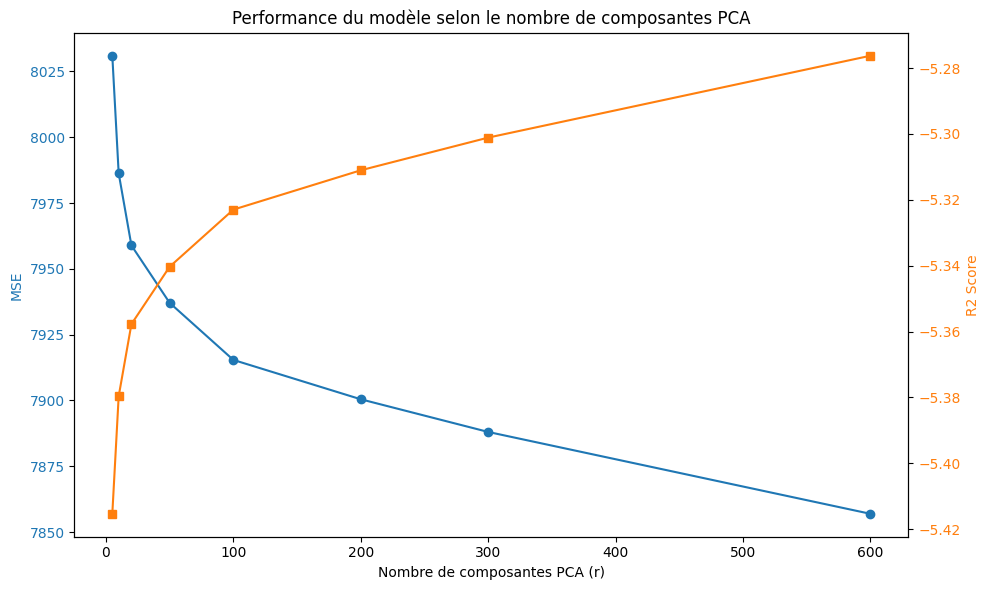

In [ ]:
## Écrivez votre code ici.
r=[5,10,20,50,100,200,300,600]
mse_list=[]
r2_list=[]
for i in r:
    pca=PCA(i)
    X_pca=pca.fit_transform(X)
    MLR_pca=MyLinearRegression()
    MLR_pca.fit(X_pca,y)
    mse_list.append(MLR_pca.mse())
    r2_list.append(MLR_pca.r2())
    
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Nombre de composantes PCA (r)')
ax1.set_ylabel('MSE', color='tab:blue')
ax1.plot(r, mse_list, color='tab:blue', marker='o', label='MSE')
ax1.tick_params(axis='y', labelcolor='tab:blue')


ax2 = ax1.twinx() 
ax2.set_ylabel('R2 Score', color='tab:orange')
ax2.plot(r, r2_list, color='tab:orange', marker='s', label='R2')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Performance du modèle selon le nombre de composantes PCA")
fig.tight_layout()
plt.show()

Écrivez votre réponse ici.

3. Pour comprendre ce qui se passe, calculez la moyenne des prédictions du modèle sur X_pca et comparez-la avec la moyenne des vrais prix y. Que remarquez-vous ? Quelle est l'origine de ce problème ?

In [13]:
## Écrivez votre code ici.
pca=PCA(500)
X_pca=pca.fit_transform(X)


MLR_pca = MyLinearRegression()
MLR_pca.fit(X_pca, y)
predictions = MLR_pca.predict(X_pca)
mean_pca=np.mean(predictions)

print(f"le prix moyen prédit est de {mean_pca:.2f} euros")
print(f"le prix moyen réel est de {y.mean():.2f} euros")

le prix moyen prédit est de 0.00 euros
le prix moyen réel est de 87.87 euros


on remarque que la moyenne des prédictions du modèle sur X_pca vaut 0
et ca par rapport au centrage des données de X_pca auteur de 0 avec la pca

## Exercice 4

La régression Ridge est une variante de la régression linéaire qui ajoute un terme de régularisation. Les équations normales deviennent :
$$\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

où $\lambda > 0$ est le paramètre de régularisation et $\mathbf{I}$ est la matrice identité. L'ajout de $\lambda \mathbf{I}$ garantit que la matrice est inversible même si $X$ n'est pas de rang plein.

1. Créez une classe `MyRidgeRegression` avec la même structure que MyLinearRegression, mais dont la méthode fit prend un paramètre supplémentaire lambda_param et utilise la formule Ridge ci-dessus. Vous pouvez réutilisez les autres méthodes. Testez votre implémentation avec `lambda_param = 1.0` sur `X` et `y`. Affichez le MSE et le $R^2$.

In [14]:
## Écrivez votre code ici.
class MyRidgeRegression(MyLinearRegression):
    def fit(self, data, output, alpha=1.0):
        features = data.shape[1]
        identity_matrix = np.eye(features)
        self.weights = np.linalg.inv(data.T @ data + alpha * identity_matrix) @ data.T @ output
        self.data = data
        self.output = output
 
MyRidgeR=MyRidgeRegression()       
MyRidgeR.fit(X,y,alpha=1.0)
print(f"le mse est de {MyRidgeR.mse():.2f} et le r2 est de {MyRidgeR.r2():.2f}")

le mse est de 191.62 et le r2 est de 0.85


2. Testez différentes valeurs de lambda $\lambda : 0.001, 0.01, 0.1, 1, 10, 100, 1000$. Pour chaque valeur, entraînez un modèle et stockez le MSE et le $R^2$ correspondants. Tracez deux courbes (échelle logarithmique pour l'axe des $x$) : MSE en fonction de $\lambda$ et $R^2$ en fonction de $\lambda$. Comment évoluent les performances en fonction de $\lambda$ ? Quelle valeur de $\lambda$ donne les meilleurs résultats sur ce dataset ?

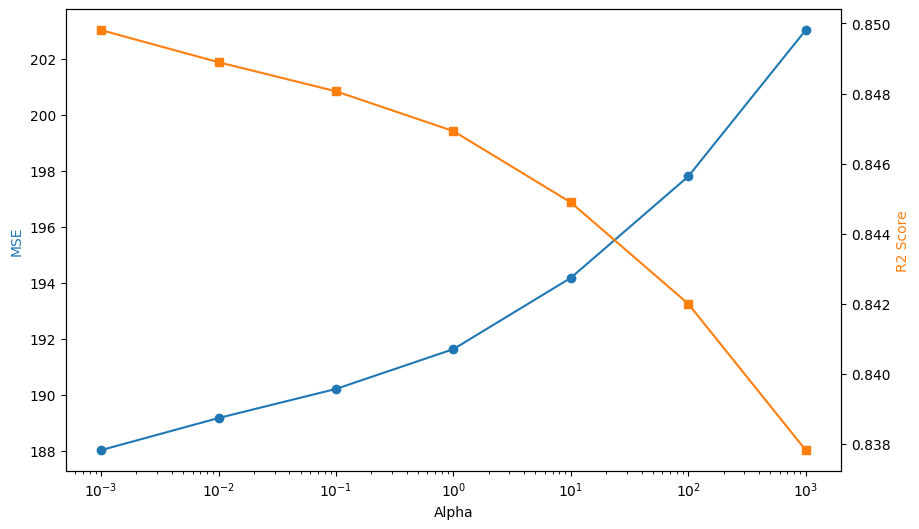

In [15]:
alpha_liste=[0.001,0.01,0.1,1,10,100,1000]
mse_ridge_list=[]
r2_ridge_list=[]
for alpha in alpha_liste:
    MyRidgeR.fit(X,y,alpha)
    mse_ridge_list.append(MyRidgeR.mse())
    r2_ridge_list.append(MyRidgeR.r2())
fig,ax1=plt.subplots(figsize=(10,6))
ax1.set_xlabel('Alpha')
ax1.set_ylabel('MSE', color='tab:blue')
ax1.plot(alpha_liste, mse_ridge_list, color='tab:blue', marker='o', label='MSE')
ax1.set_xscale('log')

ax2=ax1.twinx()
ax2.set_ylabel('R2 Score', color='tab:orange')
ax2.plot(alpha_liste, r2_ridge_list, color='tab:orange', marker='s', label='R2')
ax2.set_xscale('log')

lorsque alpha augmente :
mse augmente , le r2 diminue
on choisit alpha d'une facon qui stabilise w mais qui n'augemente pass trop la valeur du mse

## Exercice 5

Jusqu'ici, notre modèle de régression prédit une sortie comme une combinaison linéaire des entrées, sans terme constant. Ce modèle passe forcément par l'origine : si toutes les entrées sont nulles, alors la sortie prédite est nulle. En pratique, on souhaite souvent un modèle affine qui inclut un biais (intercept).

Une astuce classique consiste à ajouter une colonne de $1$ à la matrice de données, ce qui permet d'absorber le biais dans le vecteur de poids.

1. Créez une nouvelle matrice X_affine en ajoutant une colonne de $1$ à `X` avec np.c_ (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.c_.html)**). Entraînez un modèle `MyRidgeRegression` avec `lambda = 1.0` sur `X` et sur `X_affine`, et comparez les MSE et $R^2$ obtenus.

In [16]:
X_affine=np.c_[X, np.ones(X.shape[0])]
mrgr=MyRidgeRegression()
mrgr.fit(X_affine,y,alpha=1.0)
mse_aff=mrgr.mse()
r2_affine=mrgr.r2()
mrgr.fit(X,y,alpha=1.0)
mse_x=mrgr.mse()
r2_x=mrgr.r2()
print(f"le mse avec la composante affine est de {mse_aff:.2f} et le r2 est de {r2_affine:.2f}")
print(f"le mse sans la composante affine est de {mse_x:.2f} et le r2 est de {r2_x:.2f}")

le mse avec la composante affine est de 117.47 et le r2 est de 0.91
le mse sans la composante affine est de 191.62 et le r2 est de 0.85


mse_affine est plus petit que le mse avec X. 
r2_affine est plus grand que  le r2 avec X

2. Faites de même avec la PCA : projetez X sur $r = 50$ composantes, puis créez deux versions : une sans colonne de $1$ et une avec colonne de $1$. Entraînez une `MyLinearRegression` sur chacune et comparez les résultats. Que constatez-vous ? L'ajout de l'intercept améliore-t-il significativement les résultats ? Pourquoi ?

In [17]:
pca=PCA(50)
X_pca=pca.fit_transform(X)
X_pca_affine=np.c_[X_pca, np.ones(X_pca.shape[0])]
lr=MyLinearRegression()
lr.fit(X_pca,y)
print(f" sans colonne de 1 :le mse est de {lr.mse():.2f} et le r2 est de {lr.r2():.2f}")
lr.fit(X_pca_affine,y)
print(f" avec colonne de 1 :le mse est de {lr.mse():.2f} et le r2 est de {lr.r2():.2f}")


 sans colonne de 1 :le mse est de 7938.17 et le r2 est de -5.34
 avec colonne de 1 :le mse est de 216.25 et le r2 est de 0.83


on remarque qu'avec l'ajout de l'intercept, les résultat sont améliorés.
sans l'intercept : on impose à la droite de passer par 0 pour rejoindre les points ,ce qui augmente le mse
avec l'intercept : la droite se déplacera verticalement pour atteindre le centre du nuage de points ,ce qui minimise le mse

3. Maintenant que nous avons compris l'importance de l'intercept, étudiez l'impact du paramètre $\lambda$ pour Ridge avec intercept. Testez les mêmes valeurs que précédemment $(0.001, 0.01, 0.1, 1, 10, 100, 1000)$ mais cette fois sur `X_affine`. Tracez les courbes MSE et $R^2$ en fonction de $\lambda$.

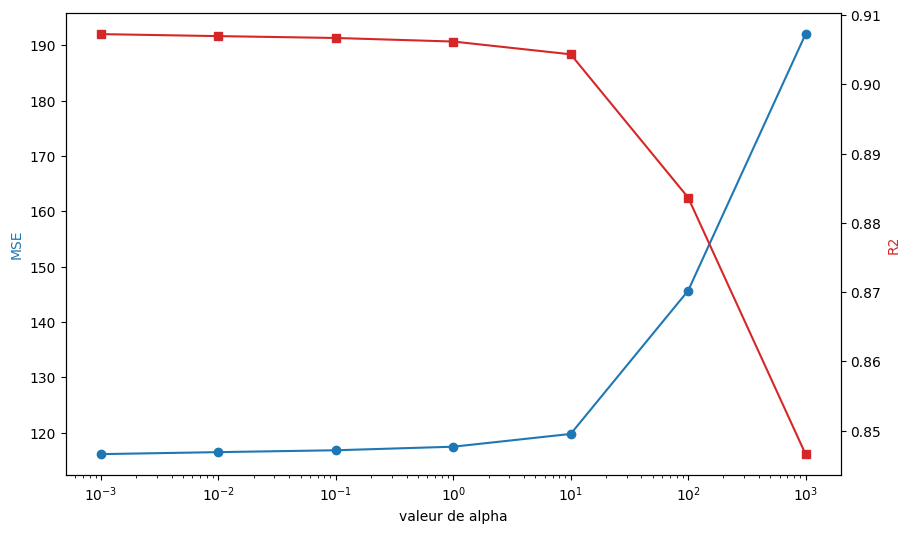

In [23]:
## Écrivez votre code ici.
X_affine=np.c_[X, np.ones(X.shape[0])]
alpha_liste=[0.001,0.01,0.1,1,10,100,1000]
mse_ridge=[]
r2_ridge=[]
MyRidgeR=MyRidgeRegression()
for alpha in alpha_liste:
    MyRidgeR.fit(X_affine,y,alpha)
    mse_ridge.append(MyRidgeR.mse())
    r2_ridge.append(MyRidgeR.r2())


fig,ax1=plt.subplots(figsize=(10,6))
ax1.set_xlabel('valeur de alpha')
ax1.set_ylabel('MSE',color='tab:blue')
ax1.plot(alpha_liste,mse_ridge,color='tab:blue',marker='o' , label='MSE')
ax1.set_xscale('log')

ax2=ax1.twinx()
ax2.set_ylabel('R2',color='tab:red')
ax2.plot(alpha_liste,r2_ridge,color='tab:red',marker='s', label='R2')
ax1.set_xscale('log')

4. De même, étudiez l'impact du nombre de composantes PCA avec intercept. Testez les mêmes valeurs que précédemment $(5, 10, 20, 50, 100, 200, 300, 600)$ mais cette fois en ajoutant systématiquement une colonne de $1$ après la projection PCA. Tracez les courbes MSE et $R^2$ en fonction de $r$.

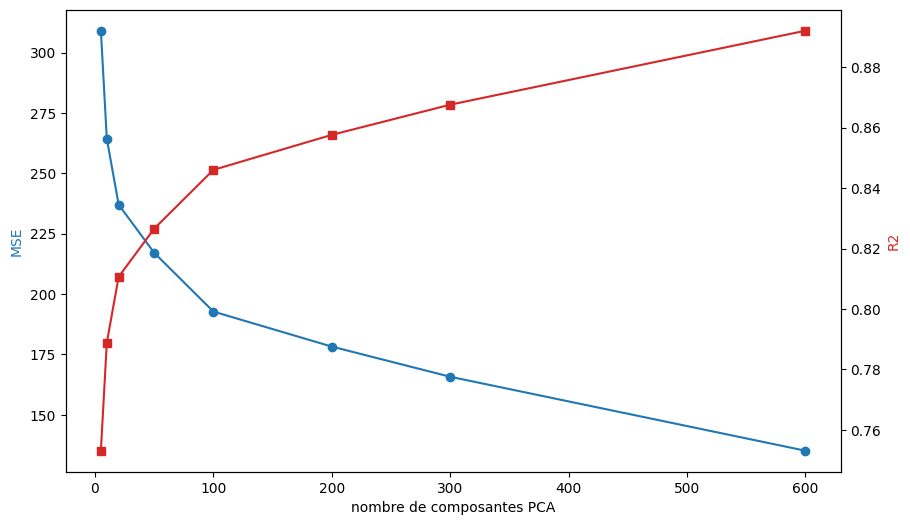

In [20]:
pca_liste=[5,10,20,50,100,200,300,600]
mse_pca_ridge=[]
r2_pca_ridge=[]
for r in pca_liste:
    pca=PCA(r)
    X_pca=pca.fit_transform(X)
    X_pca_affine=np.c_[X_pca, np.ones(X_pca.shape[0])]
    MyRidgeR.fit(X_pca_affine,y,alpha=1.0)
    mse_pca_ridge.append(MyRidgeR.mse())
    r2_pca_ridge.append(MyRidgeR.r2())
fig,ax1=plt.subplots(figsize=(10,6))
ax1.set_xlabel('nombre de composantes PCA')
ax1.set_ylabel('MSE',color='tab:blue')
ax1.plot(pca_liste,mse_pca_ridge,color='tab:blue',marker='o' , label='MSE')
ax2=ax1.twinx()
ax2.set_ylabel('R2',color='tab:red')
ax2.plot(pca_liste,r2_pca_ridge,color='tab:red',marker='s', label='R2')


5. Comparez les résultats des deux exercices précédents. Quelle approche (Ridge ou PCA) donne les meilleurs résultats avec intercept ? Quelle valeur optimale de $\lambda$ ou r observez-vous ?

L'approche Ridge avec l'intercept donne les meilleurs résultats.
Ridge: alpha=0.001  donne la valeur de mse la plus faible et le r2 le plus elevé.
PCA: r=600 